In [64]:
# commented by AC 8/4/2020 and in discussion w/ LF 8/6/2020, recommented 3/1/2021
# reminder - julia is indexed at 1 not 0!!

#import things! only needs to be done once, then can comment this away 
import Pkg;
Pkg.add("CSV")
Pkg.add("DataFrames")
#Pkg.add("AbstractDataFrame")
Pkg.add("ForwardDiff")
Pkg.add("SharedArrays")
Pkg.add("Optim")
Pkg.add("LinearAlgebra")
Pkg.add("StatsFuns")
Pkg.add("SpecialFunctions")
Pkg.add("Statistics")
Pkg.build("SpecialFunctions")
Pkg.add("Plots")
Pkg.add("PyPlot")
Pkg.add("Distributions")

In [65]:
Pkg.add("MAT")

In [1]:
using Distributed
using MAT
using Plots

parallel = true    # Run on multiple CPUs.

if (parallel)
    addprocs();
end

@everywhere using DataFrames
@everywhere using SharedArrays
@everywhere using ForwardDiff
@everywhere using Optim
@everywhere using LinearAlgebra       # for tr, diagonal
@everywhere using StatsFuns           # logsumexp
@everywhere using SpecialFunctions    # for erf
@everywhere using Statistics          # for mean

# load the EM code (these are separate .jl files)
@everywhere directory = "" #"/home/daw/winhome/Dropbox (Princeton)/expts/julia em/git/em/"
@everywhere include("em.jl");
@everywhere include("common.jl");
@everywhere include("load_data.jl");

### 1. Load files

In [2]:
rat = "peanut"

#files = [string("data/",rat,"_clean_contingencies_only_parsed_data.csv")] 
files = [string("data/",rat,"_clean_contingencies_only_parsed_data.csv")] 
hmm_file_prefix=string("hmm_",rat,"/",rat,"_day");

data = []

for i = 1:length(files)
    df = load_behavior_data(files[i],hmm_file_prefix) # add subgroup label called "sub" for em.
    
    if (i == 1)
        data = df
    else
        data =[data;df]
    end
end  


In [3]:
print(data[1,:])

DataFrameRow
 Row │ Column1  leaf   stem    reward  contingency   date      session  trial  rewscaled  stemchoice  leafchoice  daynum  sub    q1       q2       q3       q4       q5       q6      
     │ Int64    Int64  String  Int64   Int64         Int64     Int64    Int64  Int64      Int64       Int64       Int64   Int64  Float64  Float64  Float64  Float64  Float64  Float64 
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │       0      1  A            1  805020202050  20201124        2      0          1           1           1       1      1      0.0      0.0      0.0      0.0      0.0      0.0

### 2. Define model and likelihood

### (1) Likelihood function for Q learning.
#### This function performs Q learning, fit the most likely parameters for the choice models, while providing the likelihood.

In [4]:
# this is the likelihood function for the actual model

@everywhere function qlik_simulate(params,data,learn_q,mode,add_leaf)
    # mode = "likelihood"
    # these are the free parameters
    betago = params[1]   # beta for switch to alternative stem 
    betastay = params[2] # beta for current stem
    betaleaf = params[3] # beta for leaf choice on switch
    stay = params[4]     # bias toward staying
    lr = 0.5 + 0.5 * erf(params[5] / sqrt(2)) # learning rate (squashed to 0-1 using standard normal CDF)
    spatial_bias = params[6:8];

    # rename the variables for easy acccess
    r = data[:,:rewscaled]
	c1 = data[:,:stemchoice]
    c2 = data[:,:leafchoice]

    # initialize 
    lik = 0.
    lik_go=0.
    lik_stay=0.
    prevs = 0 #stem?
    prevl = 0 #leaf?
    if learn_q
        Q = zeros(typeof(betago),3,2,length(c1)+1)
        Qeff = zeros(typeof(betago),3,2,length(c1)+1)
    else
        Q = zeros(typeof(betago),3,2,length(c1)+1)
        Q_ = Matrix(data[:,[:q1,:q2,:q3,:q4,:q5,:q6]])'
        Q_ = reshape(Q_,2,3,:);
        Q_ = permutedims(Q_, [2, 1, 3]);
        Q[:,:,1:length(c1)]=Q_;
        Qeff=Q;
    end
    
    # loop over all trials
	for i = 1:length(c1)
        # restart learning each day
        if ((i>1) && (data[i,:daynum] != data[i-1,:daynum]))
            Q[:,:,i] = zeros(typeof(betago),3,2)
            prevs = 0
            prevl = 0
        end
        Qeff[:,:,i]=Q[:,:,i]
        
        # this is the (scaled) value of switching to each alternative stem
        # mean averages over both leaves
        Qstem = betago * mean(Q[:,:,i],dims=2)
        
        # spatial bias
        if prevs > 0
            other_stems=sort(setdiff([1,2,3],prevs));
            Qstem[other_stems[1]] = Qstem[other_stems[1]] + spatial_bias[prevs]
            Qeff[other_stems[1],:,i] = Qeff[other_stems[1],:,i] .+ spatial_bias[prevs]
        end
        

        # this is the (scaled) value of staying with the current stem
        # uses only the value of the next leaf
        # plus the bias toward staying
        if (prevs > 0)
            Qstem[prevs] = betastay * Q[prevs,3-prevl,i] + stay
            Qeff[prevs,:,i] = betastay .* Qeff[prevs,:,i] .+ stay
        end

        # log likelihood of stem choice (log of logistic)
		lik += Qstem[c1[i]] - logsumexp(Qstem)
        if ((i>1) && c1[i]!=c1[i-1])
            lik_go+=Qstem[c1[i]] - logsumexp(Qstem)
        else
            lik_stay+=Qstem[c1[i]] - logsumexp(Qstem)
        end
        if ((prevs != c1[i]) && add_leaf)
            # lik += Qeff[c1[i]] - logsumexp(Qeff[setdiff(1:3,prevs)])
            # log likelihood of leaf choice on switches only
            # Qeff_all[c1[i],c2[i],i]=betaleaf * Q[c1[i],c2[i],i];
            lik += betaleaf * Q[c1[i],c2[i],i] - logsumexp(betaleaf * Q[c1[i],:,i]);
        end

        # learn about the chosen leaf
        if learn_q
            Q[:,:,i+1] = Q[:,:,i]
            Q[c1[i],c2[i],i+1] = (1-lr) * Q[c1[i],c2[i],i] + lr * r[i]
        end

        prevs = c1[i]
        prevl = c2[i]
	end
    
    if mode=="lik"
        return -lik
    elseif mode=="lik_stay_go"
        return [-lik_go,-lik_stay] 
    elseif mode=="sim"
        return Q[:,:,1:length(c1)]
    elseif mode=="sim_effective"
        return Qeff[:,:,1:length(c1)]
    end
end


# these are four nested models that omit one (or all) of the decision variables
# by setting the corresponding scale to zero
# so as to test whether choices are significantly affected by each of them

# betago = params[1]   # beta for switch to alternative stem 
# betastay = params[2] # beta for current stem
# betaleaf = params[3] # beta for leaf choice on switch
# stay = params[4]     # bias toward staying
# lr = 0.5 + 0.5 * erf(params[5] / sqrt(2)) # learning rate (squashed to 0-1 using standard normal CDF)


# Model 1: no value, with spatial bias and stay bias

@everywhere qliknull(x,d) = qlik_simulate([0;0;0;x[1];x[2];x[3:5]],d,true,"lik",false)
@everywhere qliknull_ss(x,d) = qlik_simulate([0;0;0;x[1];0;x[2:4]],d,false,"lik",false)

@everywhere qliknull_stay_go(x,d) = qlik_simulate([0;0;0;x[1];x[2];x[3:5]],d,true,"lik_stay_go",false)
@everywhere qsimnull(x,d) = qlik_simulate([0;0;0;x[1];x[2];x[3:5]],d,true,"sim",false)

# Model 2: only current value, no spatial bias
@everywhere qliknogonobias(x,d) = qlik_simulate([0;x[1];0;x[2];x[3];zeros(3,1)],d,true,"lik",false)
@everywhere qliknogonobias_ss(x,d) = qlik_simulate([0;x[1];0;x[2];0;zeros(3,1)],d,false,"lik",false)

#@everywhere qliknogonobias_stay_go(x,d) = qlik_simulate([0;x[1];0;x[2:3];0],d,true,"lik_stay_go",false)

# Model 3: only current value, with spatial bias
@everywhere qliknogo(x,d) = qlik_simulate([0;x[1];0;x[2];x[3:6]],d,true,"lik",false)
@everywhere qliknogo_ss(x,d) = qlik_simulate([0;x[1];0;x[2];0;x[3:5]],d,false,"lik",false)
@everywhere qliknogo_stay_go(x,d) = qlik_simulate([0;x[1];0;x[2];x[3:6]],d,true,"lik_stay_go",false)

# Model 4: full value
@everywhere qlik(x,d) = qlik_simulate(x,d,true,"lik",false)
@everywhere qlik_ss(x,d) = qlik_simulate(x,d,false,"lik",false)
@everywhere qlik_stay_go(x,d) = qlik_simulate(x,d,true,"lik_stay_go",false) # seperate contribution of trials
@everywhere qsim(x,d) = qlik_simulate(x,d,true,"sim",false)

# no bias
@everywhere qlik_nobias(x,d) = qlik_simulate([x[1:5];0;0;0],d,true,"lik",false) # the last argument should = true if comparing number to that of Natheniel's
@everywhere qlik_nobias_ss(x,d) = qlik_simulate([x[1:5];0;0;0],d,false,"lik",false) # the last argument should = true if comparing number to that of Natheniel's

In [6]:
using MAT
initbetas = [0. 0 0 0 0 0 0 0] 
initsigma = [5., 5, 5, 5, 1, 1, 1, 1]

subs = unique(data[:,:sub]) #in this case subs is just differentiating days rather than rats/subjects, poor variable naming
NS = length(subs) #number of subjects/days
X = ones(NS) # (group level design matrix); #x group level design matrix... matrix across all days of this task)

(b,s,x,l,h) = em(data,subs,X,initbetas,initsigma,qlik_nobias_ss,emtol=1e-3, parallel=true, full=false, maxiter = 1000);
iaic_old_ss=iaic(x,l,h,b,s)
# with the 0-1 transformed learnng rate in the last column
allparams = [x (0.5 .+ 0.5 .* erf.(x[:,5] ./ sqrt(2)))]
file = string("hmm_",rat,"/",rat,"_old_model.mat")
result=Dict("x" => collect(x),"l" => collect(l),"h"=>collect(h),"b"=>collect(b),"s"=>collect(s),"allparams"=>collect(allparams))
matwrite(file,result)

(b,s,x,l,h) = em(data,subs,X,initbetas,initsigma,qlik_ss;emtol=1e-3, parallel=true, full=false, maxiter = 1000);
iaic_full_ss=iaic(x,l,h,b,s)
# with the 0-1 transformed learnng rate in the last column
allparams = [x (0.5 .+ 0.5 .* erf.(x[:,5] ./ sqrt(2)))]
file = string("hmm_",rat,"/",rat,"_full_model.mat")
result=Dict("x" => collect(x),"l" => collect(l),"h"=>collect(h),"b"=>collect(b),"s"=>collect(s),"allparams"=>collect(allparams))
matwrite(file,result)

(b,s,x,l,h) = em(data,subs,X,initbetas,initsigma,qliknull_ss;emtol=1e-3, parallel=true, full=false, maxiter = 1000);
iaic_null_ss=iaic(x,l,h,b,s)
# with the 0-1 transformed learnng rate in the last column
allparams = [x (0.5 .+ 0.5 .* erf.(x[:,5] ./ sqrt(2)))]
file = string("hmm_",rat,"/",rat,"_null_model.mat")
result=Dict("x" => collect(x),"l" => collect(l),"h"=>collect(h),"b"=>collect(b),"s"=>collect(s),"allparams"=>collect(allparams))
matwrite(file,result)

(b,s,x,l,h) = em(data,subs,X,initbetas,initsigma,qliknogo_ss;emtol=1e-3, parallel=true, full=false, maxiter = 1000);
iaic_nogo_ss=iaic(x,l,h,b,s)
# with the 0-1 transformed learnng rate in the last column
allparams = [x (0.5 .+ 0.5 .* erf.(x[:,5] ./ sqrt(2)))]
file = string("hmm_",rat,"/",rat,"_nogo_model.mat")
result=Dict("x" => collect(x),"l" => collect(l),"h"=>collect(h),"b"=>collect(b),"s"=>collect(s),"allparams"=>collect(allparams))
matwrite(file,result)

(b,s,x,l,h) = em(data,subs,X,initbetas,initsigma,qliknogonobias_ss;emtol=1e-3, parallel=true, full=false, maxiter = 1000);
iaic_nogonobias_ss=iaic(x,l,h,b,s)
# with the 0-1 transformed learnng rate in the last column
allparams = [x (0.5 .+ 0.5 .* erf.(x[:,5] ./ sqrt(2)))]
file = string("hmm_",rat,"/",rat,"_nogonobias_model.mat")
result=Dict("x" => collect(x),"l" => collect(l),"h"=>collect(h),"b"=>collect(b),"s"=>collect(s),"allparams"=>collect(allparams))
matwrite(file,result)




iter: 1001
betas: [7.14 0.24 0.0 0.0 0.0 0.0 0.0 0.0]
sigma: [1.05, 0.03, 5.0, 5.0, 1.0, 1.0, 1.0, 1.0]
free energy: -3434.350417
change: [0.0, 0.0, NaN, NaN, NaN, NaN, NaN, NaN, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
max: NaN


In [6]:
using MAT
initbetas = [0. 0 0 0 0 0 0 0] 
initsigma = [5., 5, 5, 5, 1, 1, 1, 1]

subs = unique(data[:,:sub]) #in this case subs is just differentiating days rather than rats/subjects, poor variable naming
NS = length(subs) #number of subjects/days
X = ones(NS) # (group level design matrix); #x group level design matrix... matrix across all days of this task)

(b,s,x,l,h) = em(data,subs,X,initbetas,initsigma,qlik_nobias,emtol=1e-3, parallel=true, full=false, maxiter = 1000);
iaic_old=iaic(x,l,h,b,s)
# with the 0-1 transformed learnng rate in the last column
allparams = [x (0.5 .+ 0.5 .* erf.(x[:,5] ./ sqrt(2)))]
file = string("q_learning_",rat,"/",rat,"_old_model.mat")
result=Dict("x" => collect(x),"l" => collect(l),"h"=>collect(h),"b"=>collect(b),"s"=>collect(s),"allparams"=>collect(allparams))
matwrite(file,result)

(b,s,x,l,h) = em(data,subs,X,initbetas,initsigma,qlik;emtol=1e-3, parallel=true, full=false, maxiter = 1000);
iaic_full=iaic(x,l,h,b,s)
# with the 0-1 transformed learnng rate in the last column
allparams = [x (0.5 .+ 0.5 .* erf.(x[:,5] ./ sqrt(2)))]
file = string("q_learning_",rat,"/",rat,"_full_model.mat")
result=Dict("x" => collect(x),"l" => collect(l),"h"=>collect(h),"b"=>collect(b),"s"=>collect(s),"allparams"=>collect(allparams))
matwrite(file,result)

(b,s,x,l,h) = em(data,subs,X,initbetas,initsigma,qliknull;emtol=1e-3, parallel=true, full=false, maxiter = 1000);
iaic_null=iaic(x,l,h,b,s)
# with the 0-1 transformed learnng rate in the last column
allparams = [x (0.5 .+ 0.5 .* erf.(x[:,5] ./ sqrt(2)))]
file = string("q_learning_",rat,"/",rat,"_null_model.mat")
result=Dict("x" => collect(x),"l" => collect(l),"h"=>collect(h),"b"=>collect(b),"s"=>collect(s),"allparams"=>collect(allparams))
matwrite(file,result)

(b,s,x,l,h) = em(data,subs,X,initbetas,initsigma,qliknogo;emtol=1e-3, parallel=true, full=false, maxiter = 1000);
iaic_nogo=iaic(x,l,h,b,s)
# with the 0-1 transformed learnng rate in the last column
allparams = [x (0.5 .+ 0.5 .* erf.(x[:,5] ./ sqrt(2)))]
file = string("q_learning_",rat,"/",rat,"_nogo_model.mat")
result=Dict("x" => collect(x),"l" => collect(l),"h"=>collect(h),"b"=>collect(b),"s"=>collect(s),"allparams"=>collect(allparams))
matwrite(file,result)

(b,s,x,l,h) = em(data,subs,X,initbetas,initsigma,qliknogonobias;emtol=1e-3, parallel=true, full=false, maxiter = 1000);
iaic_nogonobias=iaic(x,l,h,b,s)
# with the 0-1 transformed learnng rate in the last column
allparams = [x (0.5 .+ 0.5 .* erf.(x[:,5] ./ sqrt(2)))]
file = string("q_learning_",rat,"/",rat,"_nogonobias_model.mat")
result=Dict("x" => collect(x),"l" => collect(l),"h"=>collect(h),"b"=>collect(b),"s"=>collect(s),"allparams"=>collect(allparams))
matwrite(file,result)


iter: 1001
betas: [2.01 3.69 -0.18 0.0 0.0 0.0 0.0 0.0]
sigma: [0.04, 0.32, 0.22, 5.0, 1.0, 1.0, 1.0, 1.0]
free energy: -3434.971643
change: [0.0, 0.0, -0.0, NaN, NaN, NaN, NaN, NaN, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
max: NaN


In [7]:
print(string("full (with bias): ",iaic_full,"\n"))
print(string("no go (with bias): ",iaic_nogo,"\n"))
print(string("full (no bias): ",iaic_old,"\n"))
print(string("no go (no bias): ",iaic_nogonobias,"\n"))
print(string("null (with bias): ",iaic_null,"\n"))

full (with bias): 3340.4495923874806
no go (with bias): 3374.4886353636066
full (no bias): 3400.5388516865987
no go (no bias): 3427.4812416051445
null (with bias): 3784.165578551255


In [7]:
print(string("full (with bias): ",iaic_full_ss,"\n"))
print(string("no go (with bias): ",iaic_nogo_ss,"\n"))
print(string("full (no bias): ",iaic_old_ss,"\n"))
print(string("no go (no bias): ",iaic_nogonobias_ss,"\n"))
print(string("null (with bias): ",iaic_null_ss,"\n"))

full (with bias): 3330.1337636972057
no go (with bias): 3388.612670941062
full (no bias): 3390.6006819937775
no go (no bias): 3438.6140510475993
null (with bias): 3784.1655785516496


### Get Q values from full models

In [81]:
rat="senor";
q_learning_model=string("q_learning_",rat,"/",rat,"_full_model.mat")
result=matread(q_learning_model);
x=result["x"]

files = [string("data/",rat,"_clean_contingencies_only_parsed_data.csv")] 
hmm_file_prefix=string("hmm_",rat,"/",rat,"_day");

data = []

for i = 1:length(files)
    df = load_behavior_data(files[i],hmm_file_prefix) # add subgroup label called "sub" for em.
    
    if (i == 1)
        data = df
    else
        data =[data;df]
    end
end
Q=qsim(x,data);
#
for daynum=1:length(unique(data[:,:daynum]))
    day_ind=data[:,:daynum].==daynum;
    Q_=Q[:,:,day_ind];
    Q_ = permutedims(Q_, [2, 1, 3]);
    Q_=reshape(Q_,6,(size(Q_,3)))
    q_learning_model_path=string("q_learning_",rat,"/",rat,"_day",string(daynum),"_q_value.mat")
    matwrite(q_learning_model_path,Dict("Q"=>collect(Q_)))
end

### AIC for each day

In [45]:
rat="senor"
q_learning_model=string("q_learning_",rat,"/",rat,"_full_model.mat")
result=matread(q_learning_model);
x=result["x"]
l=result["l"]
h=result["h"]
b=result["b"]
s=result["s"]

8×8 Matrix{Float64}:
 0.000354041  0.0          0.0  0.0        …  0.0       0.0        0.0
 0.0          0.000130679  0.0  0.0           0.0       0.0        0.0
 0.0          0.0          5.0  0.0           0.0       0.0        0.0
 0.0          0.0          0.0  0.0473582     0.0       0.0        0.0
 0.0          0.0          0.0  0.0           0.0       0.0        0.0
 0.0          0.0          0.0  0.0        …  0.318721  0.0        0.0
 0.0          0.0          0.0  0.0           0.0       0.0558309  0.0
 0.0          0.0          0.0  0.0           0.0       0.0        0.557203

In [51]:
print(string("full (with bias): ",iaic_full,"\n"))
print(string("no go (with bias): ",iaic_nogo,"\n"))
print(string("full (no bias): ",iaic_old,"\n"))
print(string("no go (no bias): ",iaic_nogonobias,"\n"))
print(string("null (with bias): ",iaic_null,"\n"))

full (with bias): 3340.4495923874806
no go (with bias): 3374.4886353636066
full (no bias): 3400.5388516865987
no go (no bias): 3427.4812416051445
null (with bias): 3784.165578551255


In [66]:
m=1
model_result_file=string("hmm_",rat,"/",rat,"_",model_names[m],"_model.mat")
result=matread(model_result_file);
x=result["x"]
l=result["l"]
h=result["h"]
b=result["b"]
s=result["s"]

8×8 Matrix{Float64}:
 0.0150713  0.0      0.0  0.0        0.0  0.0       0.0       0.0
 0.0        1.26352  0.0  0.0        0.0  0.0       0.0       0.0
 0.0        0.0      5.0  0.0        0.0  0.0       0.0       0.0
 0.0        0.0      0.0  0.0291629  0.0  0.0       0.0       0.0
 0.0        0.0      0.0  0.0        1.0  0.0       0.0       0.0
 0.0        0.0      0.0  0.0        0.0  0.198406  0.0       0.0
 0.0        0.0      0.0  0.0        0.0  0.0       0.276417  0.0
 0.0        0.0      0.0  0.0        0.0  0.0       0.0       0.316716

In [67]:
daynum=1;

In [101]:
using CSV, DataFrames
rat="senor";
model_names=["full","nogo","old","nogonobias","null"]


data = load_behavior_data(string("data/",rat,"_clean_contingencies_only_parsed_data.csv"),"") # add subgroup label called "sub" for em.

iaic_q_learning=zeros(length(unique(data[:,:daynum])),length(model_names))
iaic_hmm=zeros(length(unique(data[:,:daynum])),length(model_names))

x_q_learning=zeros(8,length(unique(data[:,:daynum]))) # 8 parameters.
x_hmm=zeros(8,length(unique(data[:,:daynum]))) # 8 parameters.


for m=1:length(model_names)
    model_result_file=string("hmm_",rat,"/",rat,"_",model_names[m],"_model.mat")
    result=matread(model_result_file);
    x=result["x"]
    l=result["l"]
    h=result["h"]
    b=result["b"]
    s=result["s"]
    
    for daynum=1:length(unique(data[:,:daynum]))
        iaic_hmm[daynum,m]=iaic(reshape(x[daynum,:],1,8),l[daynum],h[:,:,daynum],b,s)
        if m==1 # only for the full model
            x_hmm[:,daynum]=x[daynum,:]
        end
    end
end

file = string("hmm_",rat,"/",rat,"_summary.mat")
result=Dict("iaic_hmm" => collect(iaic_hmm),"x_hmm" => collect(x_hmm))
matwrite(file,result)

# write out a DataFrame to csv file
df = DataFrame(iaic_hmm,model_names)
CSV.write(string("hmm_",rat,"/",rat,"_summary.csv"), df)

df = DataFrame(transpose(x_hmm),["betago","betastay","betaleaf","stay","lr","spatial_bias_stem1","spatial_bias_stem2","spatial_bias_stem3"])
CSV.write(string("hmm_",rat,"/",rat,"_parameter_summary.csv"), df)

for m=1:length(model_names)
    model_result_file=string("q_learning_",rat,"/",rat,"_",model_names[m],"_model.mat")
    result=matread(model_result_file);
    x=result["x"]
    l=result["l"]
    h=result["h"]
    b=result["b"]
    s=result["s"]
    
    for daynum=1:length(unique(data[:,:daynum]))
        iaic_q_learning[daynum,m]=iaic(reshape(x[daynum,:],1,8),l[daynum],h[:,:,daynum],b,s)
        if m==1 # only for the full model
            x_q_learning[:,daynum]=x[daynum,:]
        end
    end
end

file = string("q_learning_",rat,"/",rat,"_summary.mat")
result=Dict("iaic_q_learning" => collect(iaic_q_learning),"x_q_learning" => collect(x_q_learning))
matwrite(file,result)

# write out a DataFrame to csv file
df = DataFrame(iaic_q_learning,model_names)
CSV.write(string("q_learning_",rat,"/",rat,"_summary.csv"), df)

df = DataFrame(transpose(x_q_learning),["betago","betastay","betaleaf","stay","lr","spatial_bias_stem1","spatial_bias_stem2","spatial_bias_stem3"])
CSV.write(string("q_learning_",rat,"/",rat,"_parameter_summary.csv"), df)


"q_learning_senor/senor_parameter_summary.csv"

## notebook ends here. Below are just drafts. for session

In [236]:
#for session
# daynum=8
# dates=unique(data[:,"date"])
# row_id=data[:,"date"].==dates[daynum];
# data_short=data[row_id,:]
# data_short.sub=data_short.sub.-minimum(data_short.sub).+1;
    
# subs = unique(data_short[:,:sub]); #subgroups for em
# X = ones(length(subs)); # (group level design matrix);



In [211]:



#initbetas=[-1.9839   4.61786  0.962875  2.20517];
#initsigma = [5., 5, 5, 5];
#(b_ss,s_ss,x_ss,l_ss,h_ss) = em(data_short,subs,X,initbetas,initsigma,qlik_ss;emtol=1e-3, parallel=false, full=false, maxiter = 100);



iter: 51
betas: [1.6 4.4 0.21 1.0 0.0 0.0]
sigma: [0.01, 0.01, 0.02, 1.0, 1.0, 1.0]
free energy: -286.428585
change: [0.001103, 0.000246, 0.002221, 0.0, 0.001833, 0.001833, 0.019769, 0.018972, 0.021029, 0.0, 0.0, 0.0]
max: 0.021029


## decay

In [230]:
daynum=8
dates=unique(data[:,"date"])
row_id=data[:,"date"].==dates[daynum];
data_short=data[row_id,:]
data_short.sub=data_short.sub.-minimum(data_short.sub).+1;
    
subs = unique(data_short[:,:sub]); #subgroups for em
X = ones(length(subs)); # (group level design matrix);
    
ss_result = matread(string("hmm_decay_",rat,"/",rat,"_day",daynum,"_q_value.mat"))
Qss=ss_result["Q"];
#lr=ss_result["lr"];

data_short.q1=Qss[1,:];
data_short.q2=Qss[2,:];
data_short.q3=Qss[3,:];
data_short.q4=Qss[4,:];
data_short.q5=Qss[5,:];
data_short.q6=Qss[6,:];

initbetas = [1. 1. 1. 1. 0 0];
initsigma = [1., 1., 1., 1., 1., 1.];

In [231]:
(b,s,x,l,h) = em(data_short,subs,X,initbetas,initsigma,qlik;emtol=1e-3, parallel=false, full=false, maxiter = 50);



iter: 51
betas: [0.29 2.44 3.94 -0.6 2.26 -0.0]
sigma: [0.17, 0.15, 0.01, 0.21, 0.0, 1.0]
free energy: -931.378083
change: [0.003812, 0.000683, 8.9e-5, -0.001411, 8.0e-5, -0.00037, 0.004066, 0.010811, 0.01958, 0.002677, 0.023009, 0.0]
max: 0.023009


In [224]:


(b,s,x,l,h) = em(data_short,subs,X,initbetas,initsigma,qlik;emtol=1e-3, parallel=false, full=false, maxiter = 50);

(b_null,s_null,x_null,l_null,h_null) = em(data_short,subs,X,initbetas,initsigma,qliknull;emtol=1e-3, parallel=false, full=false, maxiter = 50);

(b_nogo,s_nogo,x_nogo,l_nogo,h_nogo) = em(data_short,subs,X,initbetas,initsigma,qliknogo;emtol=1e-3, parallel=false, full=false, maxiter = 50);

(b_nobias,s_nobias,x_nobias,l_nobias,h_nobias) = em(data_short,subs,X,initbetas,initsigma,qliknobiasnogo;emtol=1e-3, parallel=false, full=false, maxiter = 50);

using MAT
file = string("hmm_decay_",rat,"/",rat,"_day",daynum,"_qlearning_q_value.mat")
matwrite(file,Dict("x" => x,"x_null"=>x_null,"x_nogo"=>x_nogo,"x_nobias"=>x_nobias,"l" => l,"l_null"=>l_null,"l_nogo"=>l_nogo,"l_nobias"=>l_nobias))


#initbetas=[-1.9839   4.61786  0.962875  2.20517];
#initsigma = [5., 5, 5, 5];
#(b_ss,s_ss,x_ss,l_ss,h_ss) = em(data_short,subs,X,initbetas,initsigma,qlik_ss;emtol=1e-3, parallel=false, full=false, maxiter = 100);



iter: 51
betas: [1.66 3.08 0.44 1.0 0.0 0.0]
sigma: [0.05, 0.0, 0.08, 1.0, 1.0, 1.0]
free energy: -620.26151
change: [8.0e-6, 7.0e-6, 5.0e-6, 0.0, 0.032098, 0.032098, 0.00088, 0.019306, 0.002964, 0.0, 0.0, 0.0]
max: 0.032098


In [283]:
print(data_short[1,:])

DataFrameRow
 Row │ Column1  leaf   stem    reward  contingency   date      session  trial  rewscaled  stemchoice  leafchoice  daynum  sub    q1        q2        q3        q4        q5        q6       
     │ Int64    Int64  String  Int64   Int64         Int64     Int64    Int64  Int64      Int64       Int64       Int64   Int64  Float64   Float64   Float64   Float64   Float64   Float64  
─────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │    8073      4  B            0  205080205020  20201104        1      0         -1           2           2       8      1  0.442809  0.366555  0.372575  0.279264  0.379599  0.415719

In [226]:
print("null value model: \n ",round.(l_null,digits=2),'\n')
print("only current value, no biase: \n ",round.(l_nobias,digits=2),'\n')
print("only current value, biase: \n ",round.(l_nogo,digits=2),'\n') # boost with biase
print("full model: \n ",round.(l,digits=2),'\n')

null value model: 
 [158.73 161.38 180.73 139.23]
only current value, no biase: 
 [147.4 155.32 171.36 139.76]
only current value, biase: 
 [140.31 145.85 157.51 133.05]
full model: 
 [140.2 145.95 157.58 133.06]


3×3 Matrix{Float64}:
 0.6       0.214286  0.785714
 0.157895  0.638095  0.842105
 0.186047  0.813953  0.72956

3×3 Matrix{Float64}:
 0.544304  0.75      0.25
 0.862069  0.836158  0.137931
 0.769231  0.230769  0.697674

3×3 Matrix{Float64}:
 0.666667  0.0487805  0.95122
 0.9       0.655172   0.1
 0.794872  0.205128   0.734694

3×3 Matrix{Float64}:
 0.683168  0.8125    0.1875
 0.928571  0.840909  0.0714286
 0.75      0.25      0.636364

3×3 Matrix{Float64}:
 0.680851  0.333333  0.666667
 0.387097  0.663043  0.612903
 0.107143  0.892857  0.825

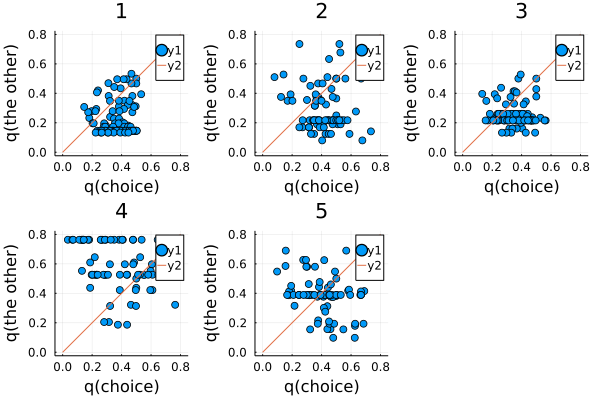

In [232]:
state_space_flag=false
#Q_full=qsim(b,data_short)
#Q_null=qsimnull(b_null,data_short)
#Q_nogo=qsimnogo(b_nogo,data_short)
using Plots;
Plots.PyPlotBackend()

subs=unique(data_short[:,:sub])
plot_array = Any[]

for s=1:length(subs)
    row_index=data_short[:,:sub].==s;
    
    if state_space_flag
        Q = Matrix(data_short[row_index,[:q1,:q2,:q3,:q4,:q5,:q6]])'
        Q = reshape(Q,2,3,:);
        Q_ = permutedims(Q, [2, 1, 3]);
    else
        Q_=qsim(x[s,:],data_short[row_index,:]);
    end
    
    T=estimate_spatial_bias(data_short[row_index,:]);
    display(T)
    
    stem_choice=data_short[row_index,:stemchoice];
    values=zeros(sum(diff(stem_choice).!=0),2)
    
    count=1
    
    for c=2:(length(stem_choice))
        if stem_choice[c-1]!=stem_choice[c]
            values[count,:]=[mean(Q_[stem_choice[c],:,c]),mean(Q_[setdiff([1,2,3],[stem_choice[c],stem_choice[c-1]]),:,c])]
            count=count+1
        end
    end
    
    if state_space_flag
        p1=plot((values[:,1]),(values[:,2]),aspect_ratio=1.0,seriestype = :scatter,title=s,xlabel = "q(choice)",ylabel = "q(the other)")
    else
        p1=plot((values[:,1].+1)./2,(values[:,2].+1)./2,aspect_ratio=1.0,seriestype = :scatter,title=s,xlabel = "q(choice)",ylabel = "q(the other)")
    end
    plot!([0,0.8],[0,0.8])
    push!(plot_array,p1)
end

plot(plot_array...)

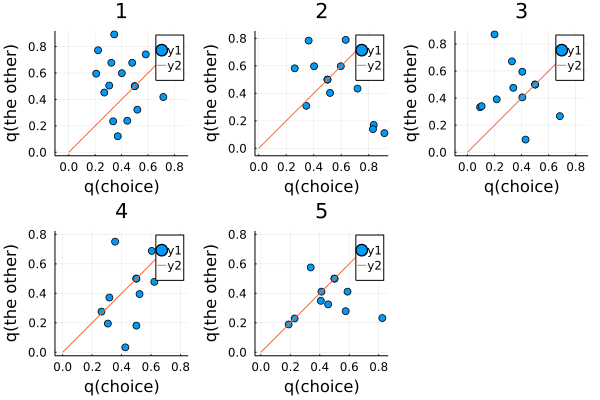

In [209]:
# leaf level
state_space_flag=false

using Plots;
Plots.PyPlotBackend()

subs=unique(data_short[:,:sub])
plot_array = Any[]

for s=1:length(subs)
    row_index=data_short[:,:sub].==s;
    
    if state_space_flag
        Q = Matrix(data_short[row_index,[:q1,:q2,:q3,:q4,:q5,:q6]])'
        Q = reshape(Q,2,3,:);
        Q_ = permutedims(Q, [2, 1, 3]);
    else
        Q_=qsim(x[s,:],data_short[row_index,:]);
    end
    
    stem_choice=data_short[row_index,:stemchoice];
    leaf_choice=data_short[row_index,:leafchoice];
    
    values=zeros(sum(diff(stem_choice).!=0),2)
    
    count=1
    
    for c=2:(length(stem_choice))
        if stem_choice[c-1]!=stem_choice[c]
            values[count,:]=[Q_[stem_choice[c],leaf_choice[c],c],Q_[stem_choice[c],3-leaf_choice[c],c]]
            count=count+1
        end
    end
    
    
    if state_space_flag
        p1=plot((values[:,1]),(values[:,2]),aspect_ratio=1.0,seriestype = :scatter,title=s,xlabel = "q(choice)",ylabel = "q(the other)")
    else
        p1=plot((values[:,1].+1)./2,(values[:,2].+1)./2,aspect_ratio=1.0,seriestype = :scatter,title=s,xlabel = "q(choice)",ylabel = "q(the other)")
    end
    plot!([0,0.8],[0,0.8])
    push!(plot_array,p1)
end

plot(plot_array...)

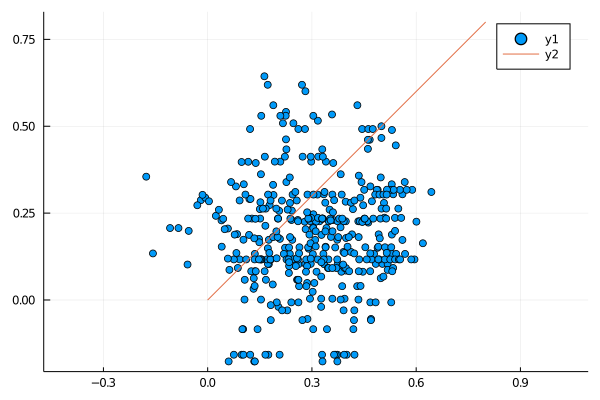

In [634]:
display(b_ss)
l_ss

1×6 Adjoint{Float64,Array{Float64,1}}:
 3.81941  7.65813  1.0  2.33849  5.75624e-8  5.75624e-8

5-element Array{Float64,1}:
 200.0494542671061
 192.70209237826464
 225.39944424692018
 204.25849514643926
 183.51169805014888

In [646]:
display(b)
l

1×6 Adjoint{Float64,Array{Float64,1}}:
 8.98886  1.0  1.0  1.0  -1.65362  -3.01554e-9

5-element Array{Float64,1}:
 42.83202646543332
 48.08405035830784
 71.16895084460528
 41.55073953016587
 40.14999405486418

In [647]:
display(b_ss)
l_ss

1×6 Adjoint{Float64,Array{Float64,1}}:
 5.9872  1.0  1.0  1.0  -2.24935e-8  -2.24935e-8

5-element Array{Float64,1}:
 59.63788543134899
 56.21945222861184
 67.1235496216242
 55.50795909953338
 49.965045324327875

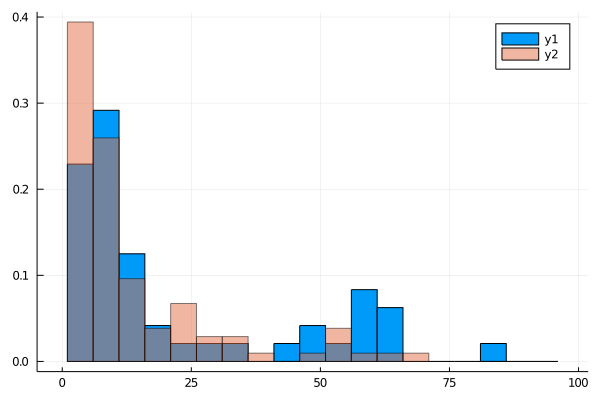

In [611]:
using Plots;
Plots.PyPlotBackend()
daynum=9
dates=unique(data[:,"date"])
row_id=data[:,"date"].==dates[daynum];
data_short=data[row_id,:]
histogram(diff(findall(diff(data_short[:,:stemchoice]).!=0)),bins=1:5:100,normalize = :probability)

daynum=5
dates=unique(data[:,"date"])
row_id=data[:,"date"].==dates[daynum];
data_short=data[row_id,:]
histogram!(diff(findall(diff(data_short[:,:stemchoice]).!=0)),bins=1:5:100,alpha=0.5,normalize = :probability)

In [616]:
display(b)
l

1×6 Adjoint{Float64,Array{Float64,1}}:
 1.29139  1.75349  1.0  3.35522  0.252749  5.33689e-9

8-element Array{Float64,1}:
 78.53254457921679
 50.28659292115525
 59.32993452972725
 31.57618657558412
 46.243222476321236
 40.442080857665395
 36.186262483698435
 30.56437324798934

In [549]:
l_ss

7-element Array{Float64,1}:
 56.27880142643611
 17.245278017075947
 28.493515658297692
 64.97073678399309
 29.51279266028884
 28.912898612043534
 23.599374222285437

In [626]:
## leaf

subs = unique(data_short[:,:sub]); #subgroups for em

l_mc=zeros(length(subs))
choice_num=zeros(length(subs))
for s=1:length(subs)
    data_test=data_short[data_short[:,:sub] .== s,:];
    leaf_choice=data_test[:,:leaf];
    
    T_hat=zeros(6,6) # 3 stems
    for c=2:(length(leaf_choice))
        T_hat[leaf_choice[c-1],leaf_choice[c]]+=1
    end
    
    T_hat=T_hat./sum(T_hat,dims=2);
end

In [627]:
T_hat

6×6 Array{Float64,2}:
 0.0       0.961538   0.0       0.0384615  0.0        0.0
 0.928571  0.0        0.0       0.0        0.0714286  0.0
 0.0       0.0        0.0       1.0        0.0        0.0
 0.0       0.0545455  0.945455  0.0        0.0        0.0
 0.0       0.0        0.0       0.2        0.0        0.8
 0.0       0.0        0.0       0.0        1.0        0.0

In [698]:
subs = unique(data_short[:,:sub]); #subgroups for em

l_mc=zeros(length(subs))
choice_num=zeros(length(subs))
for s=1:length(subs)
    data_test=data_short[data_short[:,:sub] .== s,:];
    stem_choice=data_test[:,:stemchoice];
    
    T_hat=zeros(3,3) # 3 stems
    for c=2:(length(stem_choice))
        T_hat[stem_choice[c-1],stem_choice[c]]+=1
    end
    
    T_hat=T_hat./sum(T_hat,dims=2);
    display(T_hat)
    T_hat[1,2:3]=T_hat[1,2:3]./sum(T_hat[1,2:3]);
    T_hat[2,[1,3]]=T_hat[2,[1,3]]./sum(T_hat[2,[1,3]]);
    T_hat[3,1:2]=T_hat[3,1:2]./sum(T_hat[3,1:2]);

    
    l_=0;
    choice_num_=0;
    for c=2:(length(stem_choice))
        if stem_choice[c]!=stem_choice[c-1]
            l_=l_+log(T_hat[stem_choice[c-1],stem_choice[c]])
            choice_num_=choice_num_+1
        #display(string(stem_choice[c-1],stem_choice[c]," ",T_hat[stem_choice[c-1],stem_choice[c]]))
        end
    end
    l_mc[s]=-l_
    choice_num[s]=choice_num_
end

3×3 Array{Float64,2}:
 0.625      0.03125   0.34375
 0.0406504  0.723577  0.235772
 0.0486111  0.222222  0.729167

3×3 Array{Float64,2}:
 0.809816  0.110429  0.0797546
 0.280488  0.695122  0.0243902
 0.166667  0.111111  0.722222

3×3 Array{Float64,2}:
 0.72093    0.263566  0.0155039
 0.253968   0.65873   0.0873016
 0.0681818  0.204545  0.727273

3×3 Array{Float64,2}:
 0.751351  0.0756757  0.172973
 0.485714  0.514286   0.0
 0.379747  0.0253165  0.594937

3×3 Array{Float64,2}:
 0.611111   0.305556  0.0833333
 0.0702703  0.832432  0.0972973
 0.0128205  0.269231  0.717949

In [501]:
choice_num

8-element Array{Float64,1}:
 16.0
  7.0
 11.0
  9.0
  3.0
  6.0
  7.0
  5.0

In [637]:
l_mc

5-element Array{Float64,1}:
 35.9935052679229
 38.14697934926208
 38.92335940622618
 35.74848581290017
 32.424650579426846

In [498]:
exp(-15/10)

0.22313016014842982

In [93]:
qlik_ss(b_ss,data_short)

52.59292840435674

In [43]:
display(b)
display(b_ss)

1×5 Adjoint{Float64,Array{Float64,1}}:
 0.183407  2.81154  0.999999  2.22106e-53  0.964486

1×5 Adjoint{Float64,Array{Float64,1}}:
 1.03251e-51  1.64042  1.0  3.06545e-52  9.67242e-12

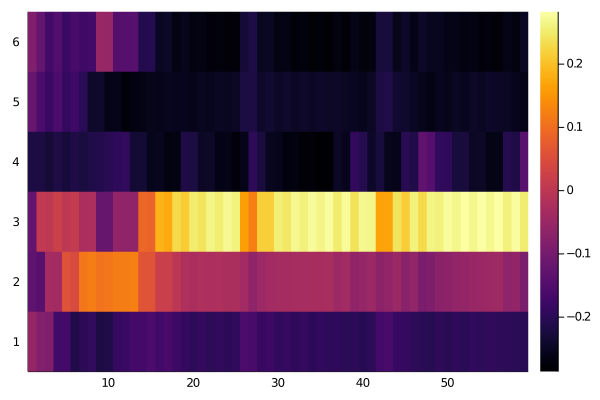

In [318]:
heatmap(ss_result["Q"][:,trial_start:trial_end].-0.5)

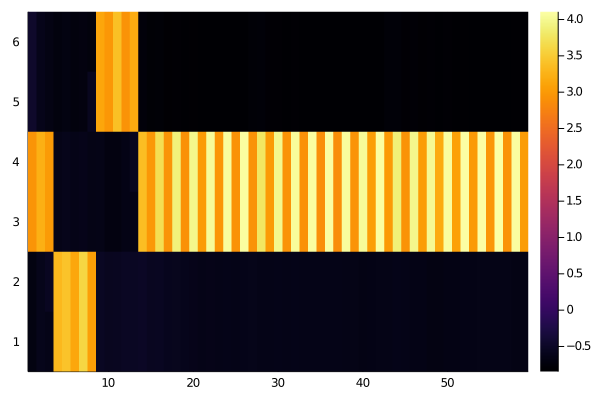

In [317]:
heatmap(Q_ss_col[:,trial_start:trial_end].-0.5)

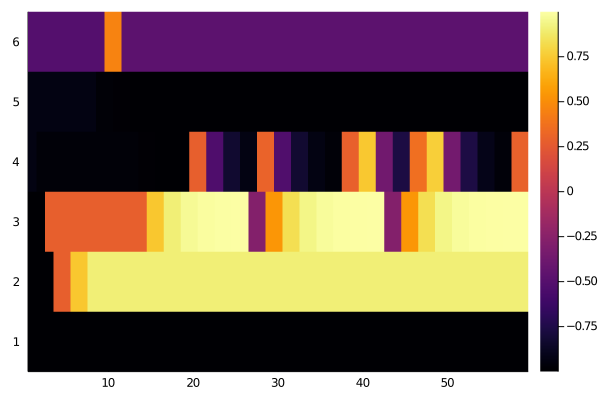

In [316]:
heatmap(Q_col[:,trial_start:trial_end])

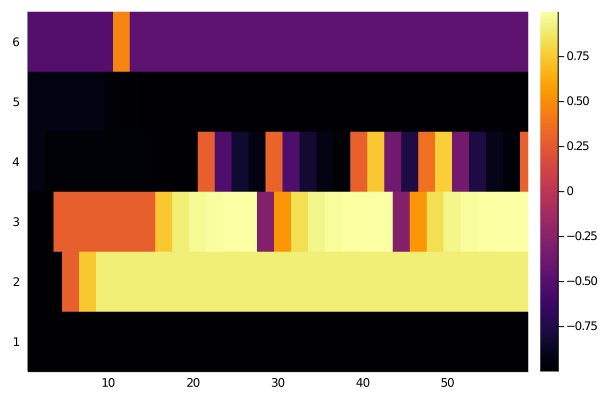

In [322]:
heatmap(Q_col[:,(trial_start-1):(trial_end-1)])

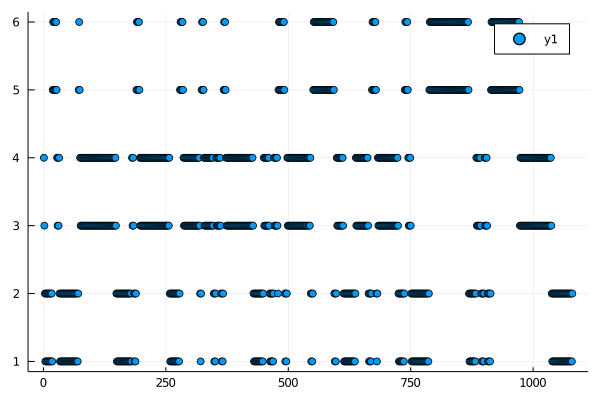

In [25]:
data_short[trial_start:trial_end,:reward][1]

0

In [28]:
cont_bounds=findall(diff(data_short[:,:contingency]).!=0)

cont_i=7;
trial_start=cont_bounds[cont_i]+1;
trial_end=cont_bounds[cont_i+1]-1;
display(unique(data_short[trial_start:trial_end,:contingency]))

Q=qsim_eff(b,data_short[trial_start:trial_end,:]);
Q_col=reshape(permutedims(Q, [2, 1, 3]),(6,:));

1-element Array{Int64,1}:
 205020205080

"1 stem choice: 2"

"1 stem choice: [1.0; 1.0; 1.0]"

"1 likelihood of stem choice: -1.0986122886681098"

"2 stem choice: 2"

...

"58 stem choice: [0.3120089314850656; 0.27515109066536114; 1.0]"

"58 likelihood of stem choice: -1.7523811811645063"

"59 stem choice: 1"

"59 stem choice: [0.3120089314850656; 0.2750366696665822; 1.0]"

"59 likelihood of stem choice: -1.6265976403441758"

In [20]:
Qss[:,:,11].+0.5

3×2 Array{Float64,2}:
 0.668436  0.514117
 0.285646  0.248185
 0.293538  0.292051

In [19]:
Qss[:,:,12].+0.5

3×2 Array{Float64,2}:
 0.717426  0.496531
 0.276898  0.24776
 0.284105  0.282871

In [29]:
ss_result = matread(string("hmm_",rat,"/",rat,"_day",daynum,"_q_value.mat"))
Qss=reshape(ss_result["Q"],2,3,:);
Qss=permutedims(Qss, [2, 1, 3]).-0.5;

Q_ss_col=qsim_ss(b,Qss[:,:,trial_start:trial_end],data_short[trial_start:trial_end,:]);
Q_ss_col=reshape(permutedims(Q_ss_col, [2, 1, 3]),(6,:));

"1 stem choice: 2"

"1 stem choice: [1.0; 1.0; 1.0]"

"1 likelihood of stem choice: -1.0986122886681098"

"2 stem choice: 2"

"2 stem choice: [0.8451276655640758; 0.9806635435238374; 0.7555969498459845]"

...

"58 stem choice: [0.8322497548772727; 0.6910306581277385; 1.0404802720890634]"

"58 likelihood of stem choice: -1.3110462865861388"

"59 stem choice: 1"

"59 stem choice: [0.8338639930951364; 0.6900119366112969; 1.0395082200404677]"

"59 likelihood of stem choice: -1.123013286747141"

16-element Array{Int64,1}:
 206420205020
 166420205020
 165120205020
 125120205020
 124020205020
 104020205020
 103220205020
  83220205020
 208020205020
 208020204020
 208020204016
  82620205020
  62620205020
 208020165020
 208016165020
 208016205020

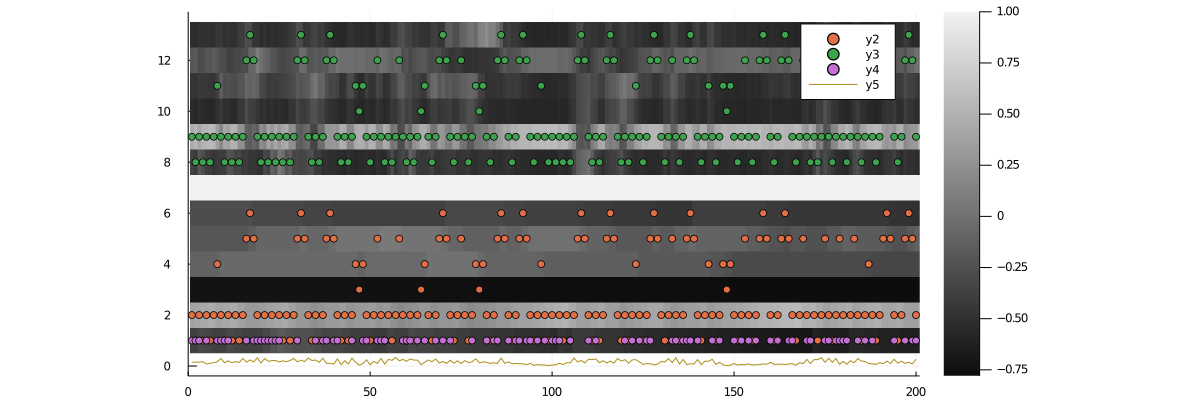

In [695]:
cont_bounds=findall(diff(data_short[:,:contingency]).!=0)

cont_i=6;
trial_start=(cont_i-1)*200#cont_bounds[cont_i]+1;
trial_end=(cont_i)*200#cont_bounds[cont_i+1]-1;
display(unique(data_short[trial_start:trial_end,:contingency]))


Q=qsim(b,data_short);
Q_col=reshape(permutedims(Q, [2, 1, 3]),(6,:));

ss_result = matread(string("hmm_decay_",rat,"/",rat,"_day",daynum,"_q_value.mat"))
Q_ss_col=(ss_result["Q"].-0.5).*2;
#Qss=reshape(ss_result["Q"],2,3,:);
#Qss=permutedims(Qss, [2, 1, 3]).-0.5;
#Q_ss_col=qsim_ss(b,Qss,data_short);
#Q_ss_col=reshape(permutedims(Q_ss_col, [2, 1, 3]),(6,:));

#display(string("state space, ",qlik_q(b_ss,Qss[:,:,trial_start:trial_end],data_short[trial_start:trial_end,:])))
#display(string("Q, ",qlik(b,data_short[trial_start:trial_end,:])))

heatmap([Q_col[:,(trial_start):(trial_end)];ones(1,trial_end-trial_start+1);Q_ss_col[:,(trial_start):(trial_end)]], color=:grays, aspect_ratio=7,size=(1200,400),xlims = (0,trial_end-trial_start+1))
plot!(1:(trial_end-trial_start),data_short[(trial_start+1):(trial_end),:stemchoice].*2 .-2 .+data_short[(trial_start+1):(trial_end),:leafchoice],seriestype = :scatter)
plot!(1:(trial_end-trial_start),data_short[(trial_start+1):(trial_end),:stemchoice].*2 .-2 .+data_short[(trial_start+1):(trial_end),:leafchoice] .+7,seriestype = :scatter)
rw_plot=data_short[(trial_start+1):(trial_end),:reward];
rw_plot=convert(Array{Float64},rw_plot)
rw_plot[iszero.(rw_plot)] .= NaN
plot!(1:(trial_end-trial_start),rw_plot,seriestype = :scatter)
plot!(1:(trial_end-trial_start),lr[(trial_start+1):(trial_end)])


In [ ]:

heatmap([Q_col[:,(trial_start-1):(trial_end-1)];ones(1,trial_end-trial_start+1);Q_ss_col[:,(trial_start-1):(trial_end-1)]], color=:grays, aspect_ratio=8,size=(1200,400),xlims = (0,trial_end-trial_start+1))
plot!(1:(trial_end-trial_start+1),data_short[trial_start:trial_end,:stemchoice].*2 .-2 .+data_short[trial_start:trial_end,:leafchoice],seriestype = :scatter)
plot!(1:(trial_end-trial_start+1),data_short[trial_start:trial_end,:stemchoice].*2 .-2 .+data_short[trial_start:trial_end,:leafchoice] .+7,seriestype = :scatter)


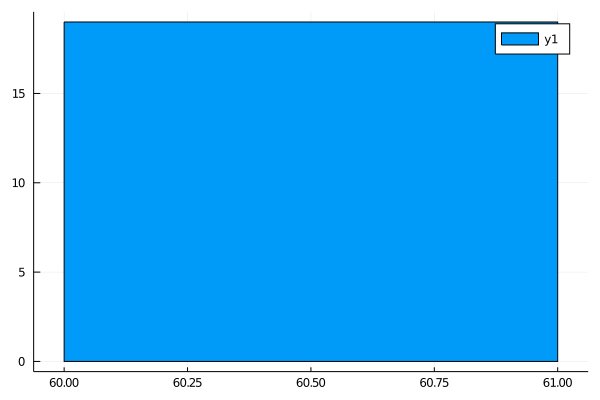

In [583]:
findall(diff(data_short[:,:session])>0)

In [68]:
l

6-element Array{Float64,1}:
 39.66594988594054
 57.667694750783774
 57.574595170075284
 53.45815304671721
 44.78540977557682
 26.97946499542096


iter: 1001
betas: [-1.55 -0.14 -3.69 3.16]
sigma: [0.0, 0.22, 32.94, 0.0]
free energy: -288.1204
change: [-6.1e-5, -0.000359, -0.0, 1.8e-5, 0.00101, 1.4e-5, 0.0, 0.00099]
max: 0.00101


In [193]:
l

6-element Array{Float64,1}:
 38.107512709399394
 55.958452492282724
 56.1463381640328
 52.035505320008774
 41.556318945730446
 25.497542035925047

In [194]:
x

6×4 Array{Float64,2}:
 -1.54661   0.186228  -8.458    3.15653
 -1.54515  -0.354573  -2.81445  3.15515
 -1.54462  -0.367263   2.98879  3.15508
 -1.54573  -0.339546  -1.5609   3.15569
 -1.54735  -0.127569  -8.14864  3.15634
 -1.55017   0.159287  -4.13718  3.15784

In [161]:

# set up the EM fitting code
# this allows parameters to vary by day

parallel = false    # Run on multiple CPUs.
full = false       # Maintain full (vs diagonal) covariance matrix (of parameters across days)  
emtol = 1e-3

using Distributed
if (parallel)
	addprocs()
end

# estimate parameters for each day
# original task
dates=unique(data[:,"date"])
lik_session=fill(NaN,maximum(data[:,"session"]),length(dates))
params_session=fill(NaN,maximum(data[:,"session"]),4,length(dates));
params_mean=fill(NaN,4,length(dates));
params_sig=fill(NaN,4,length(dates));

lik_session_q=fill(NaN,maximum(data[:,"session"]),length(dates))
params_session_q=fill(NaN,maximum(data[:,"session"]),5,length(dates));
params_mean_q=fill(NaN,5,length(dates));
params_sig_q=fill(NaN,5,length(dates));

for daynum=1#:length(dates)
    
    data_short=data[data[:,"date"].==dates[daynum],:]
    session_ends=findall(x->x!=0,diff(data_short[:,"session"]));
    session_starts=[1;session_ends.+1]; #all sessions
    
    subs = unique(data_short[:,:sub]); #subgroups for em
    X = ones(length(subs)); # (group level design matrix);
    
    ss_result = matread(string("hmm_",rat,"/",rat,"_day",daynum,"_q_value.mat"))
    Qss=reshape(ss_result["Q"],2,3,:);
    Qss=permutedims(Qss, [2, 1, 3]);
    
    @assert size(data_short,1)==size(Qss,3)
    @everywhere qlik_ss(x,d) = qlik_q(x,Qss,d) #params, data are inputs to fxn
    
    initbetas = [0. 0 0 0];
    initsigma = [5., 5, 5, 5];
        
        #start_ind=session_starts[session_index]
        #if session_index<length(session_starts)
        #    ed_ind=session_starts[session_index+1]-1
        #else
        #    ed_ind=size(data_short,1)
        #end
        #data_session=data_short[start_ind:ed_ind,:];
    
    
    #@everywhere qliknogo_ss(x,d) = qlik_q([0;x],Qss,d) #params, data are inputs to fxn
    #@everywhere qliknostay_ss(x,d) = qlik_q([x[1];0;x[2:4]],Qss,d)
    #@everywhere qliknoleaf_ss(x,d) = qlik_q([x[1:2];0;x[3:4];0],Qss,d)
    #@everywhere qliknull_ss(x,d) = qlik_q([0;0;0;x[1];0],Qss,d)
        
    (b,s,x,l,h) = em(data_short,subs,X,initbetas,initsigma,qlik_ss;emtol=1e-3, parallel=false, full=full, maxiter = 1000);
    params_session[1:size(x,1),:,daynum]=x
    params_mean[:,daynum]=b
    params_sig[:,daynum]=[s[si,si] for si=1:size(s,1)]
    lik_session[1:size(x,1),daynum]=l
    
    initbetas = [0. 0 0 0 0];
    initsigma = [5., 5, 5, 5, 1];
    
    (b,s,x,l,h) = em(data_short,subs,X,initbetas,initsigma,qlik;emtol=1e-3, parallel=false, full=full, maxiter = 1000);
    params_session_q[1:size(x,1),:,daynum]=x
    params_mean_q[:,daynum]=b
    params_sig_q[:,daynum]=[s[si,si] for si=1:size(s,1)]
    lik_session_q[1:size(x,1),daynum]=l    
    
end


iter: 1001
betas: [-1.85 4.01 0.74 1.11 -1.03]
sigma: [0.0, 0.03, 0.01, 0.0, 0.0]
free energy: -330.889824
change: [-8.0e-6, 0.0, 1.0e-6, 3.0e-6, -0.0, 0.001008, 0.000118, 0.000991, 0.000993, 0.000989]
max: 0.001008


In [2]:
lik_session

In [5]:
lik_session_q

In [162]:
lik_session_q./lik_session

8×11 Array{Float64,2}:
   0.840219  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
   0.886863  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
   0.806984  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
   0.784858  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
 NaN         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN

In [99]:
using Random
using Statistics

lik_nan=cat(reshape(lik_session_q,(:,1)),reshape(lik_session,(:,1)),dims=2);
lik=lik_nan[vec(.~(isnan.(lik_session_q))),:]
lik_boot_base=reshape(lik,(1,:));

B=10000;
ratio_boot=zeros(B);
for b=1:B
    lik_boot=reshape(lik_boot_base[randperm(MersenneTwister(b), length(lik_boot_base))],(:,2))
    ratio_boot[b]=mean(lik_boot[:,2]./lik_boot[:,1])
end
test_value=mean(lik[:,2]./lik[:,1]);
p_value=sum(Int32.(test_value.>ratio_boot))/B

0.0001

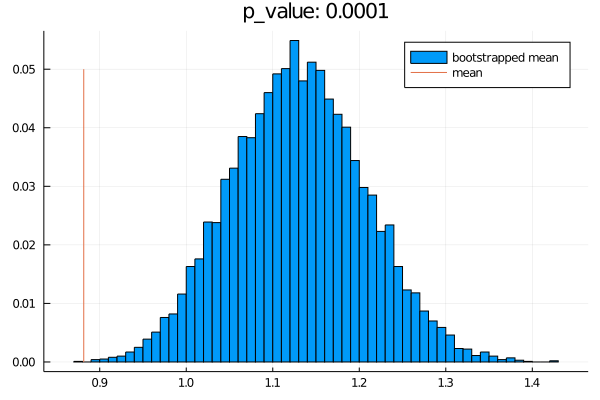

In [110]:
using Plots;
Plots.PyPlotBackend()
histogram(ratio_boot,normalize = :probability,label="bootstrapped mean")
plot!([test_value,test_value],[0,0.05],label="mean",title=string("p_value: ",string(p_value)))

In [314]:
lik

64×2 Array{Float64,2}:
 133.272   121.507
 190.738   175.856
 130.381   117.29
 NaN       NaN
 NaN       NaN
 NaN       NaN
 NaN       NaN
 NaN       NaN
 137.329   122.891
 112.014   100.586
  68.992    58.2655
  87.7545   76.6947
 124.966   112.986
   ⋮       
  84.0561   76.2181
  95.2152   86.57
  47.796    39.157
 NaN       NaN
 109.118    92.0133
  59.6327   51.8163
  75.0147   63.9816
  67.3411   57.301
  78.8385   67.6429
  71.1822   62.7739
  86.4602   79.2875
  63.4912   53.5717

In [234]:
params_session_q[:,:,8]

8×5 Array{Float64,2}:
 0.0  0.0  0.0  3.05721  0.0
 0.0  0.0  0.0  3.16976  0.0
 0.0  0.0  0.0  3.135    0.0
 0.0  0.0  0.0  3.15237  0.0
 0.0  0.0  0.0  3.12633  0.0
 0.0  0.0  0.0  3.14368  0.0
 0.0  0.0  0.0  3.109    0.0
 0.0  0.0  0.0  3.16106  0.0

In [237]:
params_sig_q

5×8 Array{Float64,2}:
 5.0        5.0       5.0       5.0       …  5.0         5.0       5.0
 5.0        5.0       5.0       5.0          5.0         5.0       5.0
 5.0        5.0       5.0       5.0          5.0         5.0       5.0
 0.0863292  0.198721  0.177581  0.200181     0.00040353  0.143104  0.00979691
 1.0        1.0       1.0       1.0          1.0         1.0       1.0

In [113]:
lik_session_q

8×8 Array{Float64,2}:
 127.268  219.931   219.931  219.931  219.931  219.931  219.931  219.931
 184.01   235.18    235.18   235.18   235.18   235.18   235.18   235.18
 124.299  219.238   219.238  219.238  219.238  219.238  219.238  219.238
 NaN      130.198   220.624  220.624  220.624  220.624  220.624  220.624
 NaN      105.601   215.079  215.079  215.079  215.079  215.079  215.079
 NaN       62.4455  206.761  206.761  206.761  206.761  206.761  206.761
 NaN       81.5456  210.227  210.227  210.227  210.227  210.227  210.227
 NaN      NaN       NaN      217.851  217.851  217.851  NaN      217.851

In [114]:
lik_session

8×8 Array{Float64,2}:
 198.184  219.931  219.931  219.931  219.931  219.931  219.931  219.931
 207.672  235.18   235.18   235.18   235.18   235.18   235.18   235.18
 121.961  219.238  219.238  219.238  219.238  219.238  219.238  219.238
 NaN      153.52   220.624  220.624  220.624  220.624  220.624  220.624
 NaN      245.137  215.079  215.079  215.079  215.079  215.079  215.079
 NaN      350.997  206.761  206.761  206.761  206.761  206.761  206.761
 NaN      286.308  210.227  210.227  210.227  210.227  210.227  210.227
 NaN      NaN      NaN      217.851  217.851  217.851  NaN      217.851

In [279]:
Q=Array{Any}(undef,length(session_starts))
for session_index=1:length(session_starts)
    data_session=data[session_starts[session_index]:min(session_ends[session_index],trial_to_try),:];
    Q[session_index]=qsim(params_session[session_index,:],data_session)
end

### End Here ###

In [9]:
# estimate parameters
# depletion task

subs2 = unique(data2[:,:sub])
NS2 = length(subs2) #AC FIXED TO BE subs2 not subs
X2 = ones(NS2) # (group level design matrix); #AC FIXED TO BE NS2 NOT NS

# fit the full model 
initbetas = [0. 0 0 0 0]
initsigma = [5., 5, 5, 5, 1]

(b2,s2,x2,l2,h2) = em(data2,subs2,X2,initbetas,initsigma,qlik; emtol=1e-3, parallel=parallel, full=full, maxiter = 1000);


iter: 7
betas: [2.52 2.66 1.71 2.02 -0.93]
sigma: [1.82, 0.6, 1.32, 0.25, 0.49]
free energy: -14083.385523
change: [9.0e-6, 1.0e-6, 8.0e-6, 1.7e-5, -5.0e-5, 0.000143, 8.0e-6, 1.3e-5, 0.00036, 0.000203]
max: 0.00036


In [11]:
Q[1,1,1:(end-1)]
#dataout.QA2 = round.(Q[1,2,1:(end-1)],digits=2)
#dataout.QB3 = round.(Q[2,1,1:(end-1)],digits=2)
#dataout.QB4 = round.(Q[2,2,1:(end-1)],digits=2)
#dataout.QC5 = round.(Q[3,1,1:(end-1)],digits=2)
#dataout.QC6 = round.(Q[3,2,1:(end-1)],digits=2)

13293-element Array{Float64,1}:
  0.0
  0.0
 -0.4778250819631961
 -0.4778250819631961
 -0.4778250819631961
 -0.4778250819631961
 -0.4778250819631961
 -0.4778250819631961
  0.2283168089531351
  0.2283168089531351
  0.2283168089531351
  0.2283168089531351
  0.2283168089531351
  ⋮
  0.5899832812194897
 -0.1697506104493245
 -0.1697506104493245
 -0.5664645930612695
 -0.5664645930612695
  0.18203147951067628
  0.18203147951067628
 -0.3827728090695906
 -0.3827728090695906
 -0.6776994421658268
 -0.6776994421658268
  0.12394743129666785

In [13]:
# write them back out in a file

dataout = data[:,1:8]
dataout.QA1 = round.(Q[1,1,1:(end-1)],digits=2)
dataout.QA2 = round.(Q[1,2,1:(end-1)],digits=2)
dataout.QB3 = round.(Q[2,1,1:(end-1)],digits=2)
dataout.QB4 = round.(Q[2,2,1:(end-1)],digits=2)
dataout.QC5 = round.(Q[3,1,1:(end-1)],digits=2)
dataout.QC6 = round.(Q[3,2,1:(end-1)],digits=2)

#=
dataout2 = data2[:,1:8]
dataout2.QA1 = round.(Q2[1,1,1:(end-1)],digits=2)
dataout2.QA2 = round.(Q2[1,2,1:(end-1)],digits=2)
dataout2.QB3 = round.(Q2[2,1,1:(end-1)],digits=2)
dataout2.QB4 = round.(Q2[2,2,1:(end-1)],digits=2)
dataout2.QC5 = round.(Q2[3,1,1:(end-1)],digits=2)
dataout2.QC6 = round.(Q2[3,2,1:(end-1)],digits=2)
=#

13293-element Array{Float64,1}:
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.48
  0.48
  0.48
  0.48
  0.48
  0.48
  ⋮
 -0.45
 -0.45
 -0.45
 -0.45
 -0.45
 -0.45
 -0.45
 -0.45
 -0.45
 -0.45
 -0.45
 -0.45

In [14]:
if saveCSV == 1 #this flag is up at the beginning of the notebook
    CSV.write(string(rat,"regular.csv"),dataout)
    CSV.write(string(rat,"depletion.csv"),dataout2)
end

In [18]:
# take a look at the parameters
# this is the group-level mean parameters (regular task) in order referenced in the function above
# so eg the stem choice is made by comparing some param value times reward expected at each "switch" stem (averaged over leaves)
# to another parm value times the reward expected for staying at the current stem (next leaf)
# plus a bias of anothe rparam value

display(b)

# the learning rate in actual units

display(0.5 + 0.5 * erf(b[5] / sqrt(2)))

1×5 Adjoint{Float64,Array{Float64,1}}:
 0.422  1.71982  0.191947  3.84964  -0.0556129

0.4778250819631961

In [15]:
# this is the group-level mean parameters (depletion task)

display(b2)

# the learning rate in actual units

display(0.5 + 0.5 * erf(b2[5] / sqrt(2)))

1×5 Adjoint{Float64,Array{Float64,1}}:
 2.52482  2.65801  1.71201  2.02302  -0.930313

0.17610461232335983

In [19]:
# these are the individual parameters session by session (regular task)
# with the 0-1 transformed learnng rate in the last column
allparams = [x (0.5 .+ 0.5 .* erf.(x[:,5] ./ sqrt(2)))]

11×6 Array{Float64,2}:
 0.420501  1.71929  0.193526  3.10024  -0.551391   0.290683
 0.422466  1.7203   0.184916  3.57058  -0.420017   0.337236
 0.421521  1.72033  0.170904  3.72539   0.157946   0.56275
 0.420391  1.72064  0.196313  3.77607   0.372705   0.645316
 0.42285   1.71947  0.186161  3.72844   0.0974056  0.538798
 0.42258   1.72008  0.192059  4.00106   0.134448   0.553476
 0.421446  1.71867  0.196624  4.17393  -0.167066   0.433659
 0.422368  1.72009  0.195451  4.10707  -0.068571   0.472666
 0.423164  1.71924  0.19372   4.22725  -0.317156   0.375563
 0.423118  1.71933  0.209369  3.87125  -0.13155    0.44767
 0.421593  1.72059  0.192369  4.06479   0.281505   0.610838

In [17]:
# these are the individual parameters session by session (depletion task)
# with the 0-1 transformed learnng rate in the last column
allparams2 = [x2 (0.5 .+ 0.5 .* erf.(x2[:,5] ./ sqrt(2)))] #fewer days so some zeros/.5s here -- hope werent included? looks like they were???? am i missing something?

13×6 Array{Float64,2}:
 0.669952  1.81968   0.549206  3.1195    0.441842   0.670698 
 0.188516  1.7375   -0.101605  2.90069   0.0213796  0.508529 
 0.153982  1.07198  -0.219436  2.40152   0.36638    0.642959 
 2.38008   2.17974   1.03653   1.85671  -1.14318    0.126481 
 2.86003   2.83948   1.98871   1.96473  -1.43274    0.0759661
 3.51091   2.32051   2.35307   1.41634  -1.36056    0.0868258
 2.95874   3.06197   2.19554   1.89224  -1.41377    0.0787149
 2.27851   2.79323   1.26071   2.06615  -1.25713    0.104353 
 2.93673   3.1306    2.10633   1.6938   -1.2074     0.113639 
 3.98268   3.72401   2.01352   1.66895  -1.30867    0.0953234
 4.1796    3.39931   2.86567   1.54687  -1.3287     0.0919742
 3.29476   3.11589   2.34993   1.86393  -0.93728    0.174307 
 3.42823   3.36023   3.85801   1.90784  -1.53423    0.0624863

┌ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80]
└ @ Base loading.jl:1278


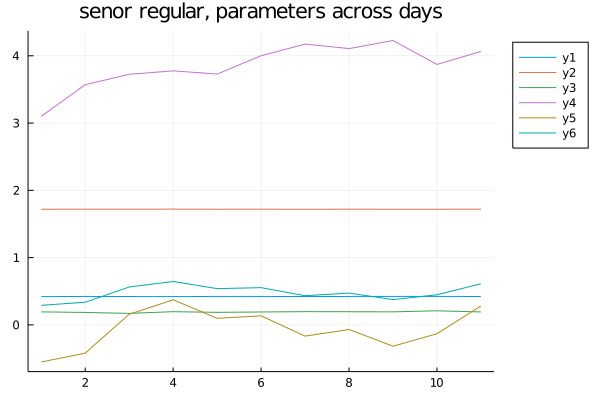

In [21]:
#checking out what happens across days to parameters
using Plots
plot(allparams)
plot!(title=string(rat," regular, parameters across days"),legend = :outertopright)

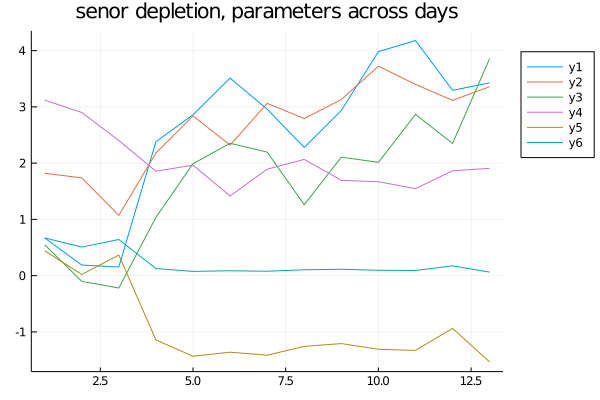

In [19]:
plot(allparams2)
plot!(title=string(rat," depletion, parameters across days"),legend = :outertopright)

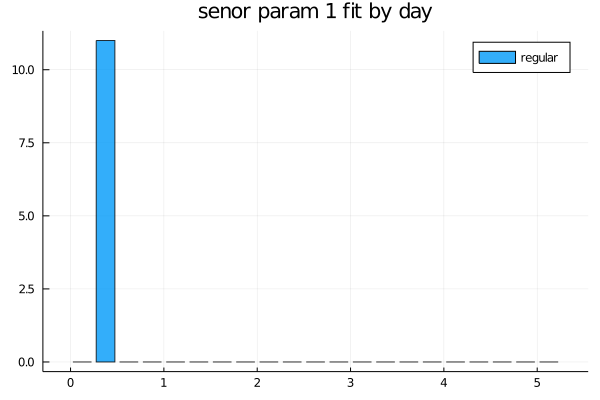

In [23]:
#still just checking out parameters
using Plots
using Distributions

param_ind = 1

paramdata = allparams[:,param_ind]
stepsize=.25
samplespace = 0:stepsize:5

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar(samplespace.+(stepsize/2),bins,label="regular",alpha=.8)

#=
paramdata = allparams2[:,param_ind]


bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar!(samplespace.+(stepsize/2),bins,label="depletion",alpha=.8)
=# 

bar!(title=string(rat," param ", param_ind," fit by day"))

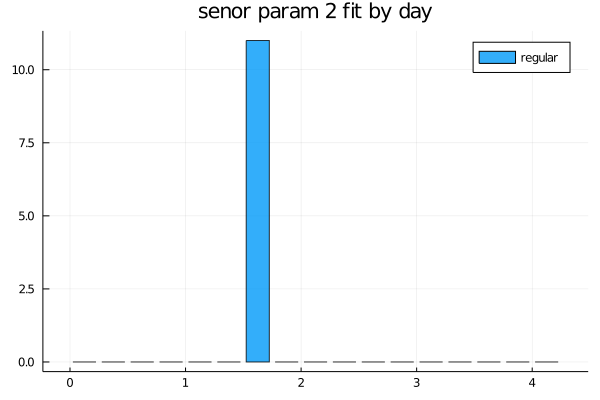

In [24]:
using Plots
using Distributions

param_ind = 2

paramdata = allparams[:,param_ind]
stepsize=.25
samplespace = 0:stepsize:4

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar(samplespace.+(stepsize/2),bins,label="regular",alpha=.8)

#=
paramdata = allparams2[:,param_ind]

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar!(samplespace.+(stepsize/2),bins,label="depletion",alpha=.8)
=#

bar!(title=string(rat," param ", param_ind," fit by day"))

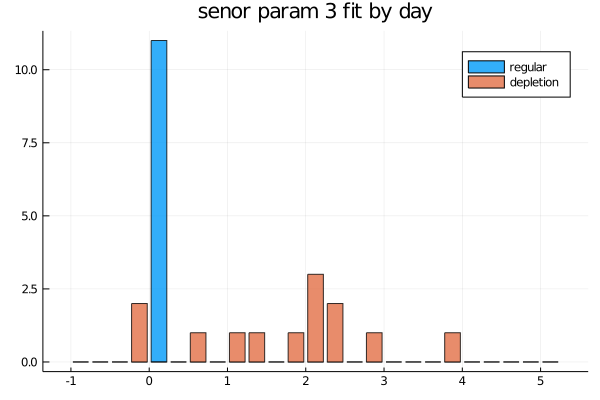

In [51]:
using Plots
using Distributions

param_ind = 3

paramdata = allparams[:,param_ind]
stepsize=.25
samplespace = -1:stepsize:5

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar(samplespace.+(stepsize/2),bins,label="regular",alpha=.8)

paramdata = allparams2[:,param_ind]

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar!(samplespace.+(stepsize/2),bins,label="depletion",alpha=.8)
    
bar!(title=string(rat," param ", param_ind," fit by day"))

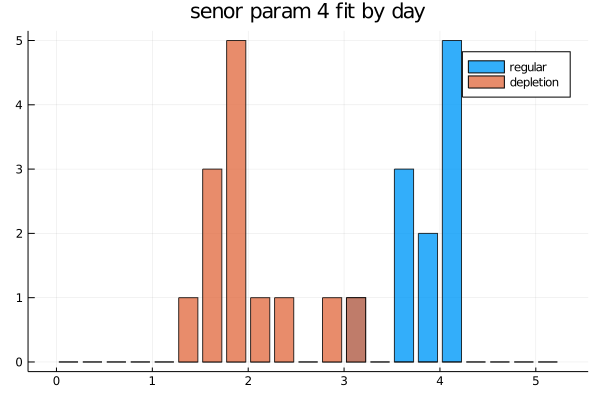

In [56]:
using Plots
using Distributions

param_ind = 4

paramdata = allparams[:,param_ind]
stepsize=.25
samplespace = 0:stepsize:5

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar(samplespace.+(stepsize/2),bins,label="regular",alpha=.8)

paramdata = allparams2[:,param_ind]

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar!(samplespace.+(stepsize/2),bins,label="depletion",alpha=.8)
    
bar!(title=string(rat," param ", param_ind," fit by day"))

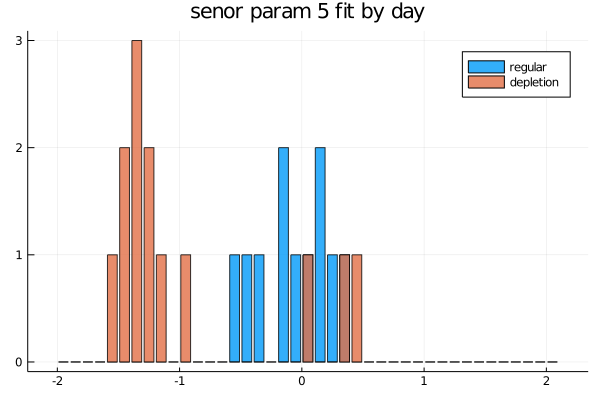

In [59]:
using Plots
using Distributions

param_ind = 5

paramdata = allparams[:,param_ind]
stepsize=.1
samplespace = -2:stepsize:2

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar(samplespace.+(stepsize/2),bins,label="regular",alpha=.8)

paramdata = allparams2[:,param_ind]

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar!(samplespace.+(stepsize/2),bins,label="depletion",alpha=.8)
    
bar!(title=string(rat," param ", param_ind," fit by day"))

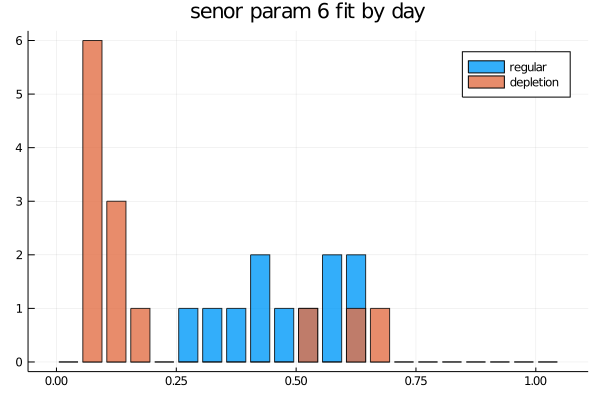

In [61]:
using Plots
using Distributions

param_ind = 6

paramdata = allparams[:,param_ind]
stepsize=.05
samplespace = 0:stepsize:1

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar(samplespace.+(stepsize/2),bins,label="regular",alpha=.8)

paramdata = allparams2[:,param_ind]

bins = [ count(x->(lb<=x<lb+stepsize),paramdata) for lb in samplespace ]
bar!(samplespace.+(stepsize/2),bins,label="depletion",alpha=.8)
    
bar!(title=string(rat," param ", param_ind," fit by day"))

In [25]:
# now fitting a bunch of nested models (with various regression weights set to 0)
# to test whether behavior is significantly modulated by each piece / see how much variance they capture

# regular task, is stem leave decision dependent on distal stem values?

initbetas = [0. 0 0 0]
initsigma = [5., 5, 5, 1]

(bnogo,snogo,xnogo,lnogo,hnogo) = em(data,subs,X,initbetas,initsigma,qliknogo; emtol=1e-3, parallel=parallel, full=full,maxiter = 1000);


iter: 992
betas: [1.71 0.19 4.05 -0.04]
sigma: [0.0, 0.0, 0.13, 0.11]
free energy: -3873.402672
change: [0.0, 1.0e-6, 0.0, -6.0e-6, 0.001, 0.000219, 0.0, 1.0e-6]
max: 0.001


In [26]:
# now fitting a bunch of nested models (with various regression weights set to 0)
# to test whether behavior is significantly modulated by various value estimates

# depletion task, is stem leave decision dependent on distal stem values?

initbetas = [0. 0 0 0]
initsigma = [5., 5, 5, 1]

(bnogo2,snogo2,xnogo2,lnogo2,hnogo2) = em(data2,subs2,X2,initbetas,initsigma,qliknogo; emtol=1e-3, parallel=parallel, full=full, maxiter = 1000);


iter: 7
betas: [2.31 1.4 2.72 -0.55]
sigma: [0.44, 0.97, 0.09, 0.48]
free energy: -14765.317323
change: [1.9e-5, 3.0e-6, 1.5e-5, -7.0e-6, 9.4e-5, 7.0e-6, 0.000835, 3.1e-5]
max: 0.000835


In [27]:
# regular task, is stem leave decision dependent on current leaf values?

(bnostay,snostay,xnostay,lnostay,hnostay) = em(data,subs,X,initbetas,initsigma,qliknostay; emtol=1e-3, parallel=parallel, full=full,maxiter = 1000);


iter: 1001
betas: [0.38 0.17 3.24 0.05]
sigma: [0.0, 0.01, 0.08, 0.0]
free energy: -4162.859935
change: [6.0e-6, 4.0e-6, 0.0, 0.000117, 0.001032, 4.7e-5, 0.0, 0.001019]
max: 0.001032


In [28]:
# depletion task, is stem leave decision dependent on current leaf values?

(bnostay2,snostay2,xnostay2,lnostay2,hnostay2) = em(data2,subs2,X2,initbetas,initsigma,qliknostay; emtol=1e-3, parallel=parallel, full=full, maxiter = 1500); 


iter: 8
betas: [3.02 1.92 1.06 -1.45]
sigma: [0.91, 1.79, 0.16, 0.04]
free energy: -15437.533994
change: [6.0e-6, 2.9e-5, 2.0e-5, -4.0e-6, 0.000788, 0.000228, 0.00044, 0.000698]
max: 0.000788


In [29]:
# regular task, any sensitivity to leaf values when arriving at new stem?

(bnoleaf,snoleaf,xnoleaf,lnoleaf,hnoleaf) = em(data,subs,X,initbetas,initsigma,qliknoleaf; emtol=1e-3, parallel=parallel, full=full,maxiter = 2000);


iter: 992
betas: [0.42 1.72 3.85 -0.06]
sigma: [0.0, 0.0, 0.11, 0.11]
free energy: -3866.268313
change: [0.0, 0.0, 0.0, -2.0e-6, 0.000987, 0.001, 0.0, 1.0e-6]
max: 0.001


In [30]:
# depletion task, any sensitivity to leaf values when arriving at new stem?

(bnoleaf2,snoleaf2,xnoleaf2,lnoleaf2,hnoleaf2) = em(data2,subs2,X2,initbetas,initsigma,qliknoleaf; emtol=1e-3, parallel=parallel, full=full, maxiter = 1500); 


iter: 7
betas: [2.3 2.57 2.05 -0.85]
sigma: [1.51, 0.53, 0.24, 0.44]
free energy: -14767.328211
change: [9.0e-6, 1.0e-6, 1.9e-5, -6.3e-5, 0.000192, 3.0e-5, 0.000435, 0.000283]
max: 0.000435


In [31]:
# regular task, no value learning at all (just a single parameter coding fixed propensity to switch stems)

initbetas = 0. 
initsigma = [5.]

(bnull,snull,xnull,lnull,hnull) = em(data,subs,X,initbetas,initsigma,qliknull; emtol=1e-3, parallel=parallel, full=full,maxiter = 1000);


iter: 7
betas: 3.43
sigma: [0.09]
free energy: -4172.602756
change: [2.0e-6, 0.000404]
max: 0.000404


In [32]:
# depletion task, no value learning at all (just a single parameter coding fixed propensity to switch stems)

initbetas = 0. 
initsigma = [5.]

(bnull2,snull2,xnull2,lnull2,hnull2) = em(data2,subs2,X2,initbetas,initsigma,qliknull; emtol=1e-3, parallel=parallel, full=full, maxiter = 1500); 


iter: 4
betas: 1.86
sigma: [0.09]
free energy: -16844.619512
change: [1.8e-5, 0.000971]
max: 0.000971


In [33]:
# regular task
# this is one measure of model goodness of fit, aggregated over sessions 
# (can get similar results using session by session cross-validation)
# smaller is better so this shows that each of the coefficients in the model
# is nonzero (ie choices depend on each of these information sources)
display(iaic(x,l,h,b,s))        # this is the full model (best)
display(iaic(xnogo,lnogo,hnogo,bnogo,snogo))   # omitting the value of stems to switch to
display(iaic(xnostay,lnostay,hnostay,bnostay,snostay))   # omitting the value of the current stem
display(iaic(xnoleaf,lnoleaf,hnoleaf,bnoleaf,snoleaf))   # omitting the value of leaves when switching stems (ie choosing leaves randomly)
display(iaic(xnull,lnull,hnull,bnull,snull))   # omitting everything and having only a fixed bias to stay (no value learning null)

3856.57318069187

3863.249437394468

4160.370478901967

3856.7568544755377

4164.099679662209

In [34]:
# depletion task
# this is one measure of model goodness of fit, aggregated over sessions 
# (can get similar results using session by session cross-validation)
# smaller is better so this shows that each of the coefficients in the model
# is nonzero (ie choices depend on each of these information sources)

## thing to note: on this task overall likelihood is much higher (worse fit)
## but this is because the null model explains so much less, which is good (ie the "good fit" in the other case is just predicting "stay")
## the likelihood ratio between the full and null models is much much better than the other task 
## meaning the learning model is doing much much more to explain choices in this version

display(iaic(x2,l2,h2,b2,s2))        # this is the full model (best)
display(iaic(xnogo2,lnogo2,hnogo2,bnogo2,snogo2))   # omitting the value of stems to switch to
display(iaic(xnostay2,lnostay2,hnostay2,bnostay2,snostay2))   # omitting the value of the current stem 
display(iaic(xnoleaf2,lnoleaf2,hnoleaf2,bnoleaf2,snoleaf2))   # omitting the value of leaves when switching stems (ie choosing leaves randomly)
display(iaic(xnull2,lnull2,hnull2,bnull2,snull2))   # omitting everything and having only a fixed bias to stay (no value learning null)

13979.113546087292

14692.689855907229

15373.293909745425

14687.40076857379

16826.170796302406

In [697]:
(3863-3856)/3856

0.0018153526970954357

In [696]:
(14692-13979)/13979

0.05100507904714214